<style>
h1, h1 *, 
h2, h2 *, 
h3, h3 *, 
h4, h4 *, 
h5, h5 *, 
h6, h6 * {
  font-family: "Times New Roman", Times, serif !important;
}
</style>

## **Faye**

<style>
h1, h1 *, 
h2, h2 *, 
h3, h3 *, 
h4, h4 *, 
h5, h5 *, 
h6, h6 * {
  font-family: "Times New Roman", Times, serif !important;

</style>

### **Stock Price Prediction - Long Short-Term Memory (LSTM)**

---

In [3]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from matplotlib import rcParams
import torch
import torch.nn as nn
import torch.optim as optim
from tensorflow.keras.layers import Dense, Dropout, LSTM
from tensorflow.keras.models import Sequential
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import root_mean_squared_error

In [12]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [13]:
aapl_ticker = "AAPL"
aapl_df = yf.download(aapl_ticker, '2020-01-01')
aapl_df.info()

C:\Users\dilan\AppData\Local\Temp\ipykernel_22644\2981815999.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  aapl_df = yf.download(aapl_ticker, '2020-01-01')
[*********************100%***********************]  1 of 1 completed

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1625 entries, 2020-01-02 to 2026-06-22
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   1625 non-null   float64
 1   (High, AAPL)    1625 non-null   float64
 2   (Low, AAPL)     1625 non-null   float64
 3   (Open, AAPL)    1625 non-null   float64
 4   (Volume, AAPL)  1625 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 76.2 KB


In [14]:
aapl_df

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.333862,72.394070,71.091169,71.344039,135480400
2020-01-03,71.630646,72.389265,71.406674,71.563213,146322800
2020-01-06,72.201416,72.239950,70.503554,70.754021,118387200
2020-01-07,71.861847,72.466330,71.642689,72.211049,108872000
2020-01-08,73.017830,73.318870,71.565614,71.565614,132079200
...,...,...,...,...,...
2026-06-15,296.420013,297.779999,291.700012,294.119995,45732600
2026-06-16,299.239990,300.480011,293.970001,295.250000,39874400


In [15]:
aapl_df.shape

(1625, 5)

In [16]:
aapl_df.isnull().sum()

Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

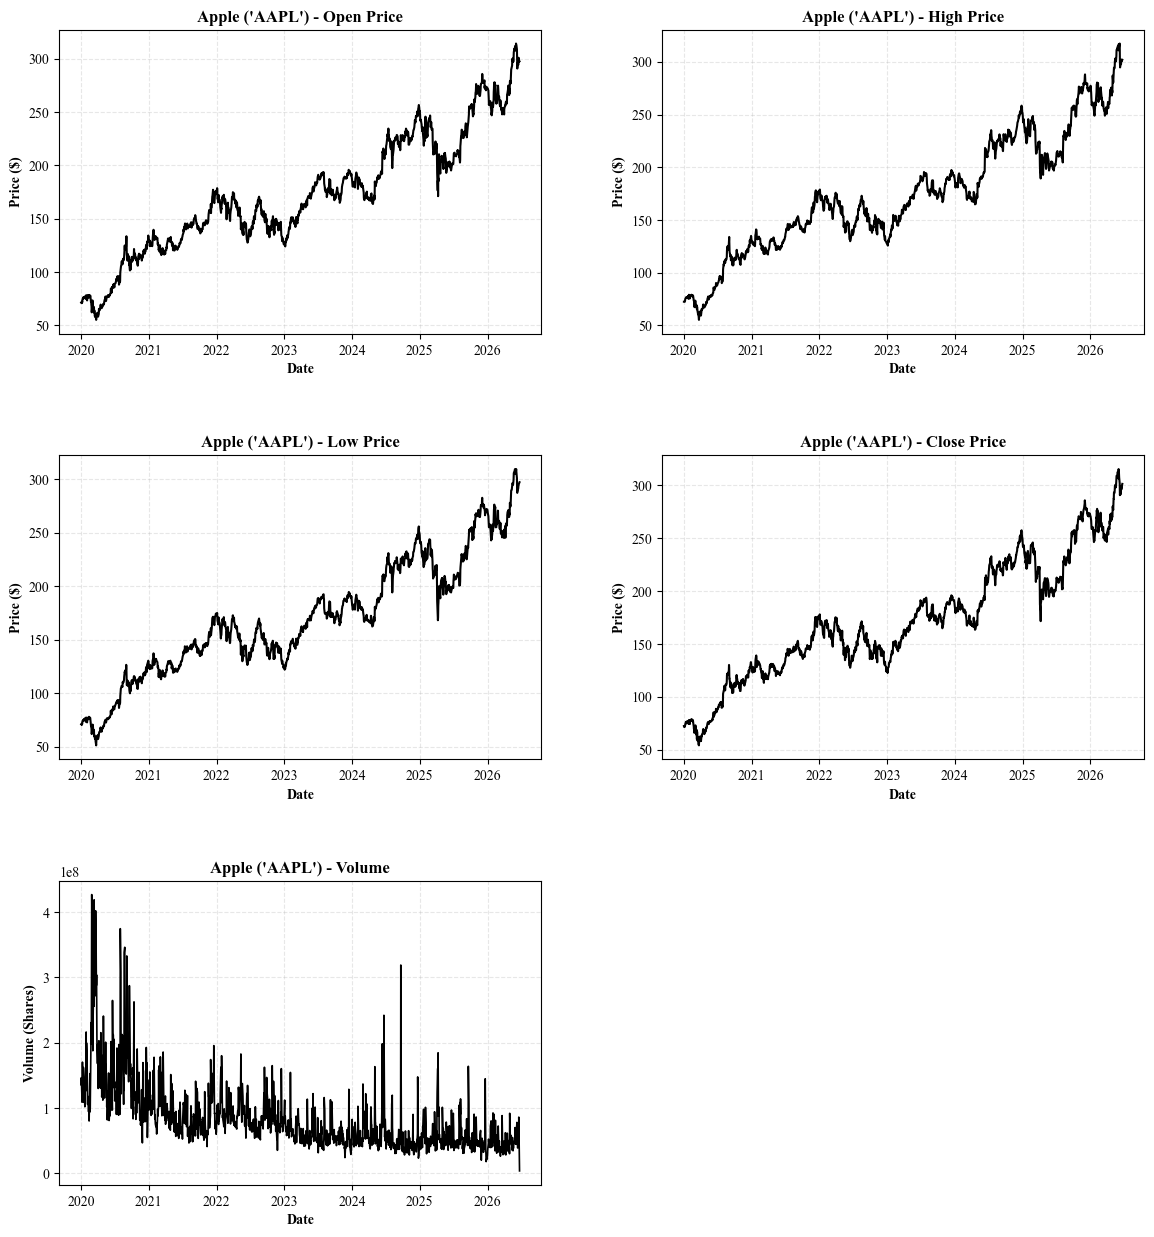

In [17]:
rcParams['font.family'] = 'Times New Roman'

fig, axes = plt.subplots(3, 2, figsize = (14, 15))

axes[0, 0].plot(aapl_df.index, aapl_df['Open'], color = 'black', linewidth = 1.5)
axes[0, 0].set_title("Apple ('AAPL') - Open Price", fontweight = 'bold', fontsize = 12)
axes[0, 0].set_xlabel("Date", fontweight = 'bold')
axes[0, 0].set_ylabel("Price ($)", fontweight = 'bold')
axes[0, 0].grid(True, linestyle = '--', alpha = 0.3)

axes[0, 1].plot(aapl_df.index, aapl_df['High'], color = 'black', linewidth = 1.5)
axes[0, 1].set_title("Apple ('AAPL') - High Price", fontweight = 'bold', fontsize = 12)
axes[0, 1].set_xlabel("Date", fontweight = 'bold')
axes[0, 1].set_ylabel("Price ($)", fontweight = 'bold')
axes[0, 1].grid(True, linestyle = '--', alpha = 0.3)

axes[1, 0].plot(aapl_df.index, aapl_df['Low'], color = 'black', linewidth = 1.5)
axes[1, 0].set_title("Apple ('AAPL') - Low Price", fontweight = 'bold', fontsize = 12)
axes[1, 0].set_xlabel("Date", fontweight = 'bold')
axes[1, 0].set_ylabel("Price ($)", fontweight = 'bold')
axes[1, 0].grid(True, linestyle = '--', alpha = 0.3)

axes[1, 1].plot(aapl_df.index, aapl_df['Close'], color = 'black', linewidth = 1.5)
axes[1, 1].set_title("Apple ('AAPL') - Close Price", fontweight = 'bold', fontsize = 12)
axes[1, 1].set_xlabel("Date", fontweight = 'bold')
axes[1, 1].set_ylabel("Price ($)", fontweight = 'bold')
axes[1, 1].grid(True, linestyle = '--', alpha = 0.3)

fig.delaxes(axes[2, 1]) 
axes[2, 0].set_position([0.125, 0.1, 0.775, 0.2]) 

axes[2, 0].plot(aapl_df.index, aapl_df['Volume'], color = 'black', linewidth = 1.2)
axes[2, 0].set_title("Apple ('AAPL') - Volume", fontweight = 'bold', fontsize = 12)
axes[2, 0].set_xlabel("Date", fontweight = 'bold')
axes[2, 0].set_ylabel("Volume (Shares)", fontweight = 'bold')
axes[2, 0].grid(True, linestyle = '--', alpha = 0.3)

plt.subplots_adjust(hspace = 0.4, wspace = 0.25)
plt.show()

In [50]:
scaler = StandardScaler()
aapl_df['Close'] = scaler.fit_transform(aapl_df['Close'])
aapl_df['Close']

Ticker,AAPL
Date,
2020-01-02,-1.801035
2020-01-03,-1.813693
2020-01-06,-1.803419
2020-01-07,-1.809531
2020-01-08,-1.788724
...,...
2026-06-15,2.232424
2026-06-16,2.283182
2026-06-17,2.223964


In [51]:
seq_length = 30
data = []

for i in range(len(aapl_df) - seq_length):
    data.append(aapl_df['Close'][i : i + seq_length])

data = np.array(data)

data

array([[[-1.801035  ],
        [-1.81369261],
        [-1.80341898],
        ...,
        [-1.71425749],
        [-1.68127715],
        [-1.69140123]],

       [[-1.81369261],
        [-1.80341898],
        [-1.80953108],
        ...,
        [-1.68127715],
        [-1.69140123],
        [-1.69105366]],

       [[-1.80341898],
        [-1.80953108],
        [-1.78872386],
        ...,
        [-1.69140123],
        [-1.69105366],
        [-1.71690802]],

       ...,

       [[ 2.00740018],
        [ 2.06728363],
        [ 2.06602463],
        ...,
        [ 2.13720562],
        [ 2.2324236 ],
        [ 2.28318202]],

       [[ 2.06728363],
        [ 2.06602463],
        [ 2.17176507],
        ...,
        [ 2.2324236 ],
        [ 2.28318202],
        [ 2.22396377]],

       [[ 2.06602463],
        [ 2.17176507],
        [ 2.16510477],
        ...,
        [ 2.28318202],
        [ 2.22396377],
        [ 2.26104288]]], shape=(1595, 30, 1))

In [52]:
train_size = int(0.8 * len(data))

X_train = torch.from_numpy(data[: train_size, :-1, :]).type(torch.Tensor).to(device)
y_train = torch.from_numpy(data[: train_size, -1, :]).type(torch.Tensor).to(device)
X_test = torch.from_numpy(data[train_size:, :-1, :]).type(torch.Tensor).to(device)
y_test = torch.from_numpy(data[train_size:, -1, :]).type(torch.Tensor).to(device)

In [53]:
X_train

tensor([[[-1.8010],
         [-1.8137],
         [-1.8034],
         ...,
         [-1.7058],
         [-1.7143],
         [-1.6813]],

        [[-1.8137],
         [-1.8034],
         [-1.8095],
         ...,
         [-1.7143],
         [-1.6813],
         [-1.6914]],

        [[-1.8034],
         [-1.8095],
         [-1.7887],
         ...,
         [-1.6813],
         [-1.6914],
         [-1.6911]],

        ...,

        [[ 1.0081],
         [ 1.1583],
         [ 1.1780],
         ...,
         [ 1.1179],
         [ 1.1106],
         [ 1.1775]],

        [[ 1.1583],
         [ 1.1780],
         [ 1.1464],
         ...,
         [ 1.1106],
         [ 1.1775],
         [ 0.9700]],

        [[ 1.1780],
         [ 1.1464],
         [ 1.1179],
         ...,
         [ 1.1775],
         [ 0.9700],
         [ 0.8511]]])

In [54]:
y_train

tensor([[-1.6914],
        [-1.6911],
        [-1.7169],
        ...,
        [ 0.9700],
        [ 0.8511],
        [ 0.7820]])

In [55]:
X_test

tensor([[[1.1464],
         [1.1179],
         [0.9750],
         ...,
         [0.9700],
         [0.8511],
         [0.7820]],

        [[1.1179],
         [0.9750],
         [1.0607],
         ...,
         [0.8511],
         [0.7820],
         [0.6513]],

        [[0.9750],
         [1.0607],
         [1.0548],
         ...,
         [0.7820],
         [0.6513],
         [0.7195]],

        ...,

        [[2.0074],
         [2.0673],
         [2.0660],
         ...,
         [2.2182],
         [2.1372],
         [2.2324]],

        [[2.0673],
         [2.0660],
         [2.1718],
         ...,
         [2.1372],
         [2.2324],
         [2.2832]],

        [[2.0660],
         [2.1718],
         [2.1651],
         ...,
         [2.2324],
         [2.2832],
         [2.2240]]])

In [56]:
y_test

tensor([[ 0.6513],
        [ 0.7195],
        [ 0.7287],
        [ 0.7052],
        [ 0.7509],
        [ 0.7304],
        [ 0.8051],
        [ 0.8492],
        [ 0.9032],
        [ 0.8635],
        [ 0.9050],
        [ 0.7985],
        [ 0.8742],
        [ 0.8932],
        [ 0.9057],
        [ 0.5351],
        [ 0.2699],
        [ 0.1460],
        [-0.0158],
        [ 0.4574],
        [ 0.3065],
        [ 0.4449],
        [ 0.5231],
        [ 0.5163],
        [ 0.3754],
        [ 0.4239],
        [ 0.3555],
        [ 0.4733],
        [ 0.5603],
        [ 0.6278],
        [ 0.6441],
        [ 0.6595],
        [ 0.6787],
        [ 0.7018],
        [ 0.7165],
        [ 0.5738],
        [ 0.4581],
        [ 0.4513],
        [ 0.4108],
        [ 0.4330],
        [ 0.4517],
        [ 0.6761],
        [ 0.7145],
        [ 0.7037],
        [ 0.6880],
        [ 0.6846],
        [ 0.6401],
        [ 0.6057],
        [ 0.5201],
        [ 0.5071],
        [ 0.3979],
        [ 0.4864],
        [ 0.

In [57]:
class PredictionModel(nn.Module):
    
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        super(PredictionModel, self).__init__()
        
        self.num_layers = num_layers
        self.hidden_dim = hidden_dim

        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first = True, dropout = 0.2)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device = device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device = device)

        out, (hn, cn) = self.lstm(x, (h0.detach(), c0.detach()))
        out = self.fc(out[:, -1, :])

        return out

In [58]:
model = PredictionModel(input_dim = 1, hidden_dim = 32, num_layers = 2, output_dim = 1).to(device)

In [59]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr = 0.01)

In [60]:
num_epochs = 200

for i in range(num_epochs):
    
    y_train_pred = model(X_train)
    loss = criterion(y_train_pred, y_train)
    
    if i % 25 == 0:
        print(i, loss.item())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

0 0.6332011222839355
25 0.013166623190045357
50 0.007726537063717842
75 0.0064435116946697235
100 0.006020696368068457
125 0.005611032713204622
150 0.005705523304641247
175 0.005176412872970104


In [61]:
model.eval()

y_test_pred = model(X_test)

y_train_pred = scaler.inverse_transform(y_train_pred.detach().cpu().numpy())
y_train = scaler.inverse_transform(y_train.detach().cpu().numpy())
y_test_pred = scaler.inverse_transform(y_test_pred.detach().cpu().numpy())
y_test = scaler.inverse_transform(y_test.detach().cpu().numpy())

In [62]:
train_rmse = root_mean_squared_error(y_train[:, 0], y_train_pred[:, 0])
test_rmse = root_mean_squared_error(y_test[:, 0], y_test_pred[:, 0])
print(f" Training RMSE: {train_rmse}")
print(f" Test RMSE: {test_rmse}")

 Training RMSE: 0.07347940653562546
 Test RMSE: 0.2147323340177536


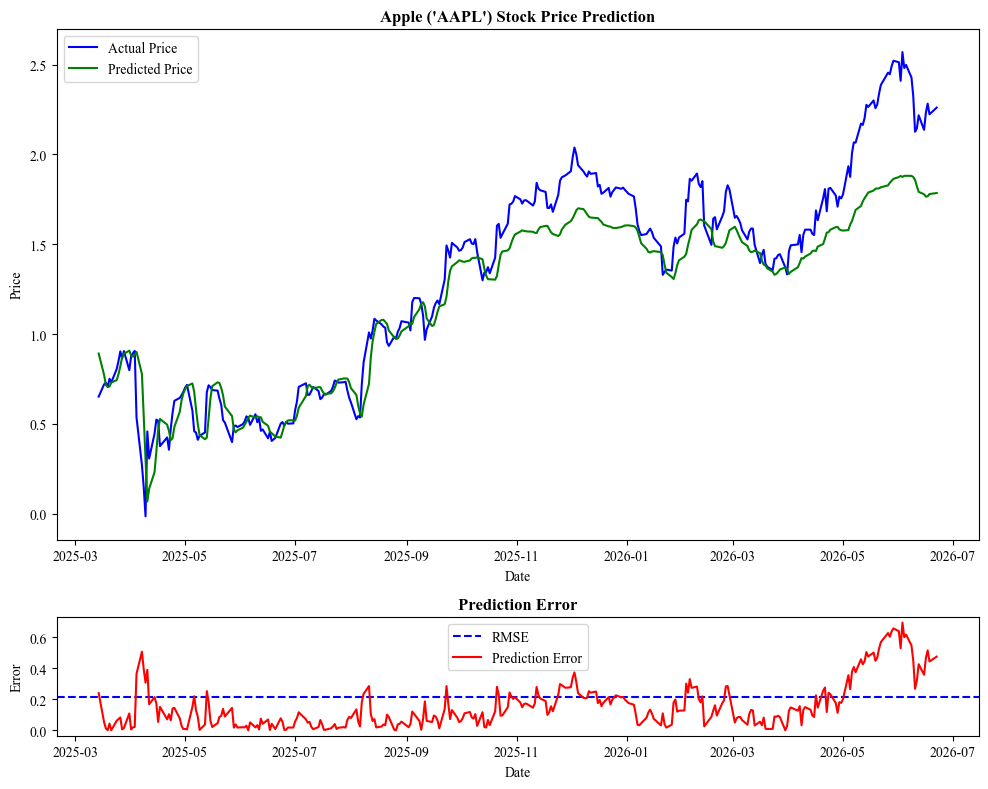

In [66]:
fig = plt.figure(figsize = (10, 8))

grid_space = fig.add_gridspec(4, 1)

ax1 = fig.add_subplot(grid_space[:3, 0])
ax1.plot(aapl_df.iloc[-len(y_test):].index, y_test, color = 'blue', label = 'Actual Price')
ax1.plot(aapl_df.iloc[-len(y_test):].index, y_test_pred, color = 'green', label = 'Predicted Price')
ax1.legend()

ax1.set_title(f"Apple ('{aapl_ticker}') Stock Price Prediction", fontweight = 'bold', fontsize = 12)
ax1.set_xlabel('Date')
ax1.set_ylabel('Price')

ax2 = fig.add_subplot(grid_space[3, 0])
ax2.axhline(test_rmse, color = 'blue', linestyle = '--', label = 'RMSE')
ax2.plot(aapl_df.iloc[-len(y_test):].index, abs(y_test - y_test_pred), 'r', label = 'Prediction Error')
ax2.legend()
ax2.set_title('Prediction Error', fontweight = 'bold', fontsize = 12)
ax2.set_xlabel('Date')
ax2.set_ylabel('Error')

plt.tight_layout()
plt.show()